In [60]:
cnv_summary <- read.delim2("/home/mjehangir/telomere-sv-analysis/data//cnvs_summary_rate_prop_pq.tsv", header = TRUE)
head(cnv_summary)

,ID,chrom,Arm,Gain_Loss,Arm_Length,total_cnv_length,segment_count,arm_length_mb,cnv_rate_per_mb,cnv_proportion_per_mb,arm
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,2436A,chr1,q,Gain,124339061,0.200152,1,124.339061,0.00804252494716845,0.00160972745322566,chr1q
2,2436A,chr10,q,Loss,94108943,17.220193,2,94.108943,0.0212519653950422,0.182981472865974,chr10q
3,2436A,chr15,q,Gain,82566565,1.602465,1,82.566565,0.0121114400241793,0.0194081587383464,chr15q
4,2436A,chr18,q,Loss,62092914,0.200356,1,62.092914,0.0161048972512387,0.00322671279366918,chr18q
5,2436A,chr19,q,Loss,33914441,7.012181,1,33.914441,0.0294859644008285,0.206760919338166,chr19q
6,2436A,chr2,p,Loss,93503283,0.200081,1,93.503283,0.0106948116463462,0.00213982860901258,chr2p


In [61]:
telomere_data <- read.delim2("/home/mjehangir/telomere-sv-analysis/data/telomere_data_fig3_cnvs.tsv", header = TRUE)
head(telomere_data)

,Sample_prefix,chr,final_average_TL_p75,chr_order,arm,final_average_TL_p75_kb,direction,TL_group
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,2436A,chr1p,5221,1,p,5.221,Negative,Other
2,2436A,chr1q,5051.16666666667,1,q,5.05116666666667,Negative,Other
3,3188,chr1p,1642.5,1,p,1.6425,Negative,Short TL
4,3188,chr1q,3086.5,1,q,3.0865,Negative,Short TL
5,3988,chr1p,2347.5,1,p,2.3475,Negative,Other
6,3988,chr1q,5083,1,q,5.083,Negative,Other


In [62]:
# Ensure both datasets have matching 'arm' column format
cnv_data <- cnv_summary %>%
  mutate(arm = paste0(chrom, Arm))  # e.g., "chr10q"

# Merge based on sample ID and arm
merged_cnv_data <- cnv_data %>%
  left_join(telomere_data, by = c("ID" = "Sample_prefix", "arm" = "chr")) %>%
  filter(!is.na(final_average_TL_p75))  # Filter out rows with missing telomere info

# View result
head(merged_cnv_data)


,ID,chrom,Arm,Gain_Loss,Arm_Length,total_cnv_length,segment_count,arm_length_mb,cnv_rate_per_mb,cnv_proportion_per_mb,arm,final_average_TL_p75,chr_order,arm.y,final_average_TL_p75_kb,direction,TL_group
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,2436A,chr1,q,Gain,124339061,0.200152,1,124.339061,0.00804252494716845,0.00160972745322566,chr1q,5051.16666666667,1,q,5.05116666666667,Negative,Other
2,2436A,chr10,q,Loss,94108943,17.220193,2,94.108943,0.0212519653950422,0.182981472865974,chr10q,2732.75,10,q,2.73275,Positive,Other
3,2436A,chr15,q,Gain,82566565,1.602465,1,82.566565,0.0121114400241793,0.0194081587383464,chr15q,4111.5,15,q,4.1115,Negative,Other
4,2436A,chr18,q,Loss,62092914,0.200356,1,62.092914,0.0161048972512387,0.00322671279366918,chr18q,3629.5,18,q,3.6295,Positive,Other
5,2436A,chr19,q,Loss,33914441,7.012181,1,33.914441,0.0294859644008285,0.206760919338166,chr19q,4544.5,19,q,4.5445,Positive,Other
6,2436A,chr2,p,Loss,93503283,0.200081,1,93.503283,0.0106948116463462,0.00213982860901258,chr2p,4118.25,2,p,4.11825,Negative,Other


In [63]:
exists("merged_cnv_data"); names(merged_cnv_data)


[1] TRUE

[1] "ID"                      "chrom"                  
 [3] "Arm"                     "Gain_Loss"              
 [5] "Arm_Length"              "total_cnv_length"       
 [7] "segment_count"           "arm_length_mb"          
 [9] "cnv_rate_per_mb"         "cnv_proportion_per_mb"  
[11] "arm"                     "final_average_TL_p75"   
[13] "chr_order"               "arm.y"                  
[15] "final_average_TL_p75_kb" "direction"              
[17] "TL_group"

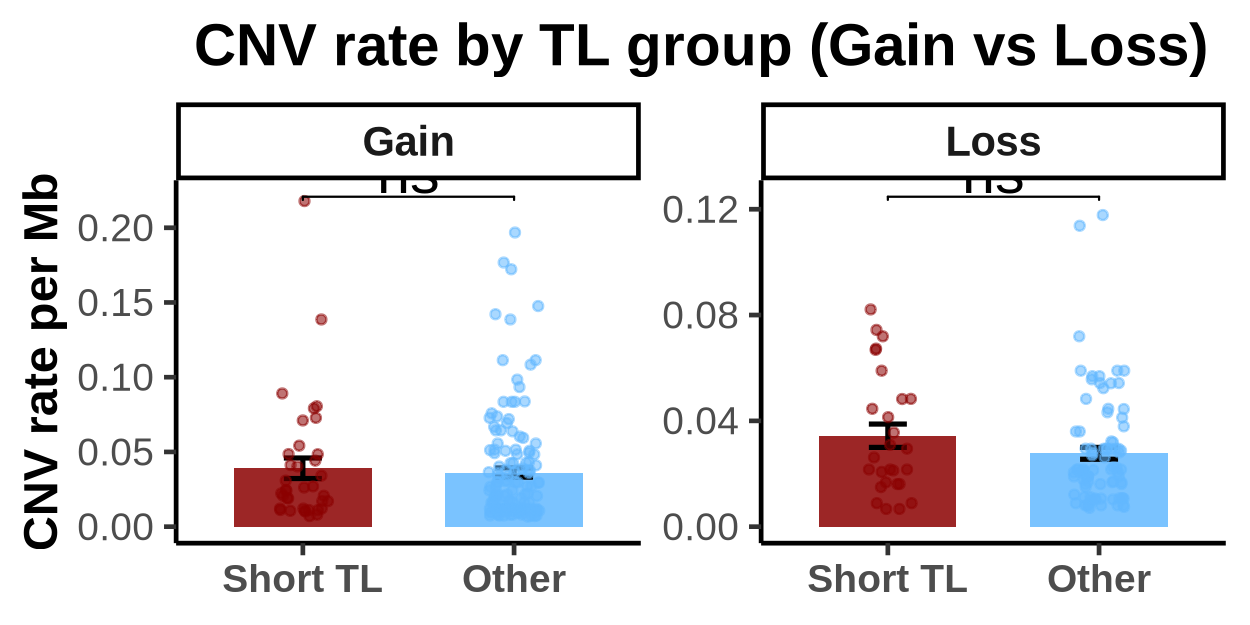

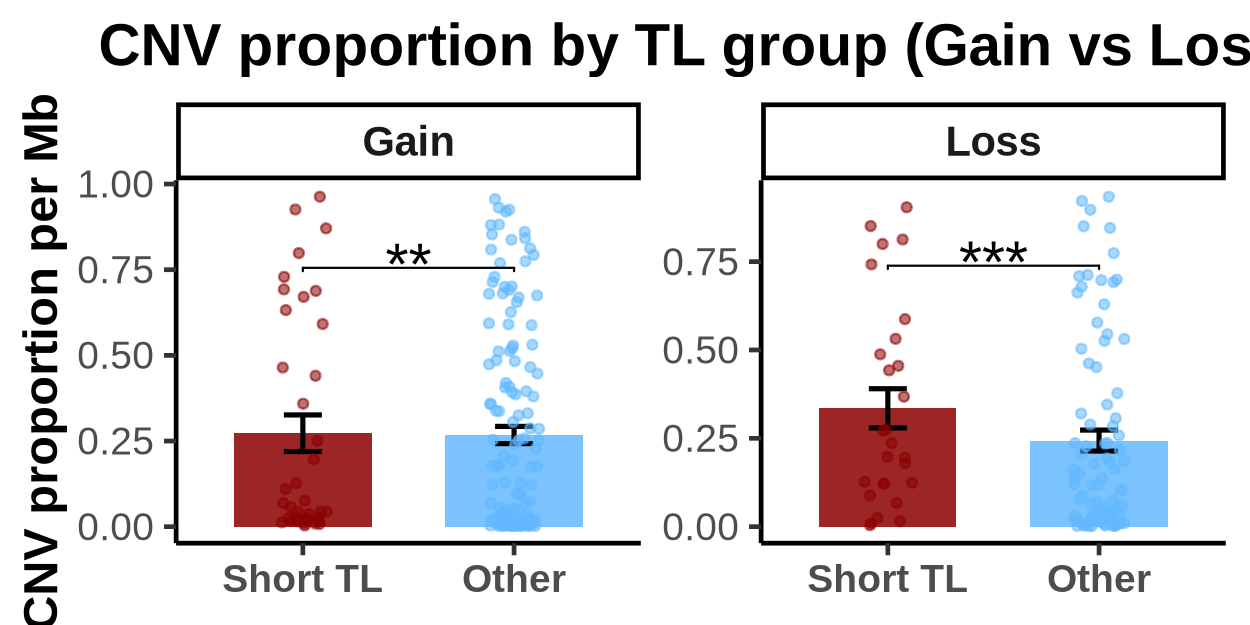

In [64]:
library(dplyr)
library(ggplot2)
library(ggpubr)
library(clubSandwich)

p_to_stars <- function(p) {
  ifelse(is.na(p), "NA",
         ifelse(p < 0.001, "***",
                ifelse(p < 0.01, "**",
                       ifelse(p < 0.05, "*", "ns"))))
}

make_cnv_gainloss_bar <- function(df, ycol, ylab, title_text) {

  d <- df %>%
    transmute(
      ID        = factor(ID),
      arm       = factor(arm),
      Gain_Loss = factor(Gain_Loss),
      TL_group  = factor(TL_group, levels = c("Short TL", "Other")),
      y_raw     = as.numeric(.data[[ycol]]),
      y         = log1p(as.numeric(.data[[ycol]]))
    ) %>%
    filter(is.finite(y))

  pvals <- d %>%
    group_split(Gain_Loss) %>%
    lapply(function(dd) {
      fit <- lm(y ~ TL_group + arm + ID, data = dd)
              #fit <- lm(y ~ TL_group + ID, data = dd)

      ct  <- clubSandwich::coef_test(fit, vcov = "CR2", cluster = dd$ID)
      p   <- ct["TL_groupOther", "p_Satt"]

      data.frame(
        Gain_Loss  = unique(dd$Gain_Loss),
        group1 = "Short TL", group2 = "Other",
        y.position = max(dd$y, na.rm = TRUE) * 1.12,
        p = as.numeric(p),
        p.signif = p_to_stars(as.numeric(p))
      )
    }) %>%
    bind_rows()

  ggplot(d, aes(x = TL_group, y = y_raw, fill = TL_group)) +
    stat_summary(fun = mean, geom = "col", width = 0.65, alpha = 0.85) +
    stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.18, linewidth = 0.7) +
    geom_jitter(aes(color = TL_group), width = 0.12, size = 1, alpha = 0.55) +
    facet_wrap(~ Gain_Loss, nrow = 1, scales = "free_y") +
    ggpubr::stat_pvalue_manual(
      pvals,
      label = "p.signif",
      tip.length = 0.01,
      size = 6,
      inherit.aes = FALSE   # <-- THIS FIXES your error
    ) +
    scale_fill_manual(values = c("Short TL" = "darkred", "Other" = "steelblue1")) +
    scale_color_manual(values = c("Short TL" = "darkred", "Other" = "steelblue1")) +
    labs(
      title = title_text,
      #subtitle = "Bars = mean ± SE; stars from patient fixed effects + CR2 robust p-values",
      x = NULL, y = ylab
    ) +
    theme_classic(base_size = 14) +
    theme(
      strip.text = element_text(face = "bold", size = 12),
      axis.title.y = element_text(face = "bold"),
      axis.text.x = element_text(face = "bold"),
      plot.title = element_text(face = "bold", hjust = 0.5),
      plot.subtitle = element_text(hjust = 0.5),
      legend.position = "none"
    )
}

options(repr.plot.width = 5, repr.plot.height = 2.5, repr.plot.res = 250)

p_cnv_rate_gainloss <- make_cnv_gainloss_bar(
  merged_cnv_data,
  ycol = "cnv_rate_per_mb",
  ylab = "CNV rate per Mb",
  title_text = "CNV rate by TL group (Gain vs Loss)"
)

p_cnv_prop_gainloss <- make_cnv_gainloss_bar(
  merged_cnv_data,
  ycol = "cnv_proportion_per_mb",
  ylab = "CNV proportion per Mb",
  title_text = "CNV proportion by TL group (Gain vs Loss)"
)

print(p_cnv_rate_gainloss)
print(p_cnv_prop_gainloss)


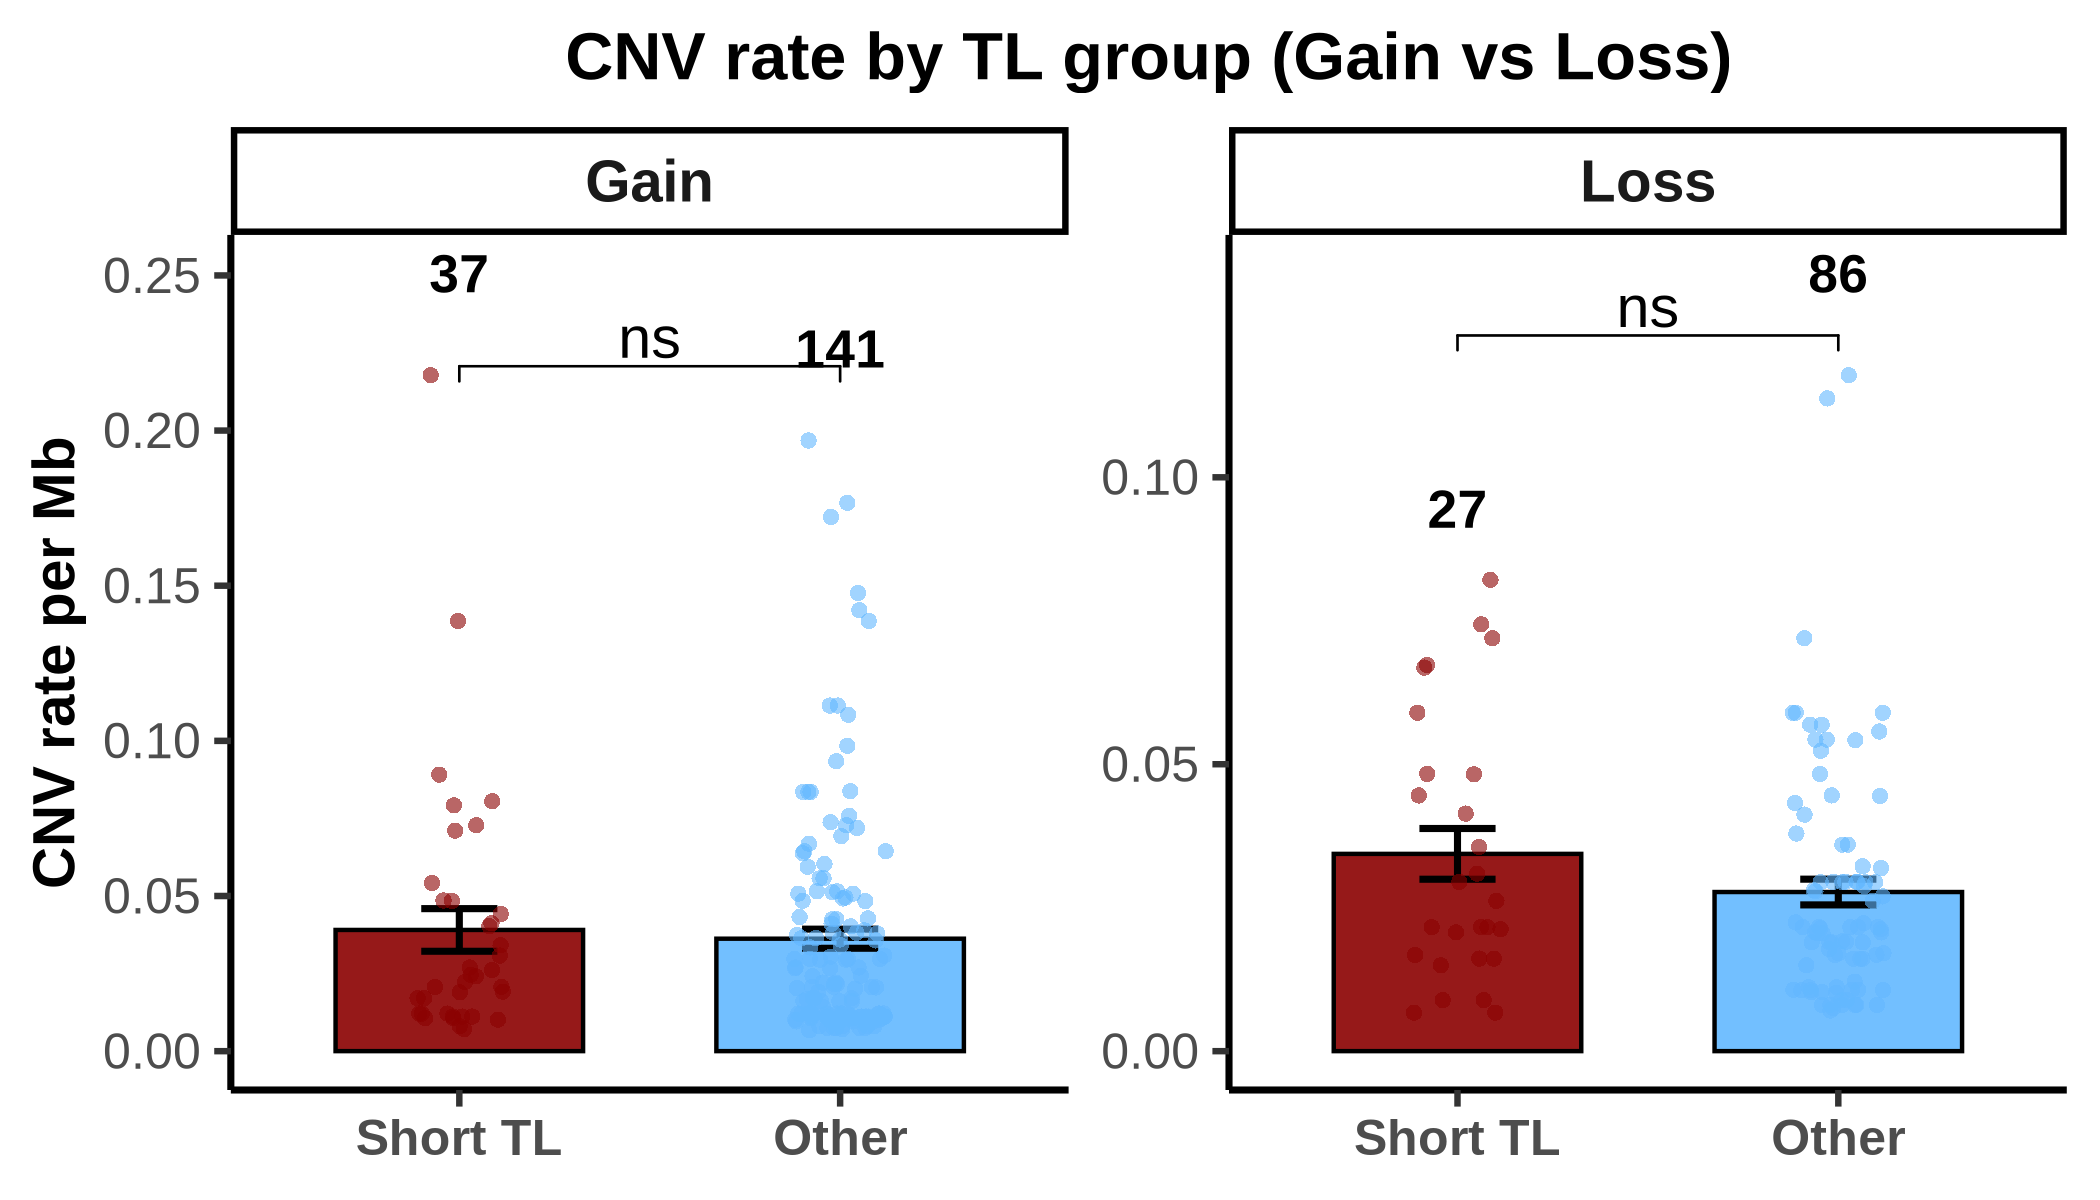

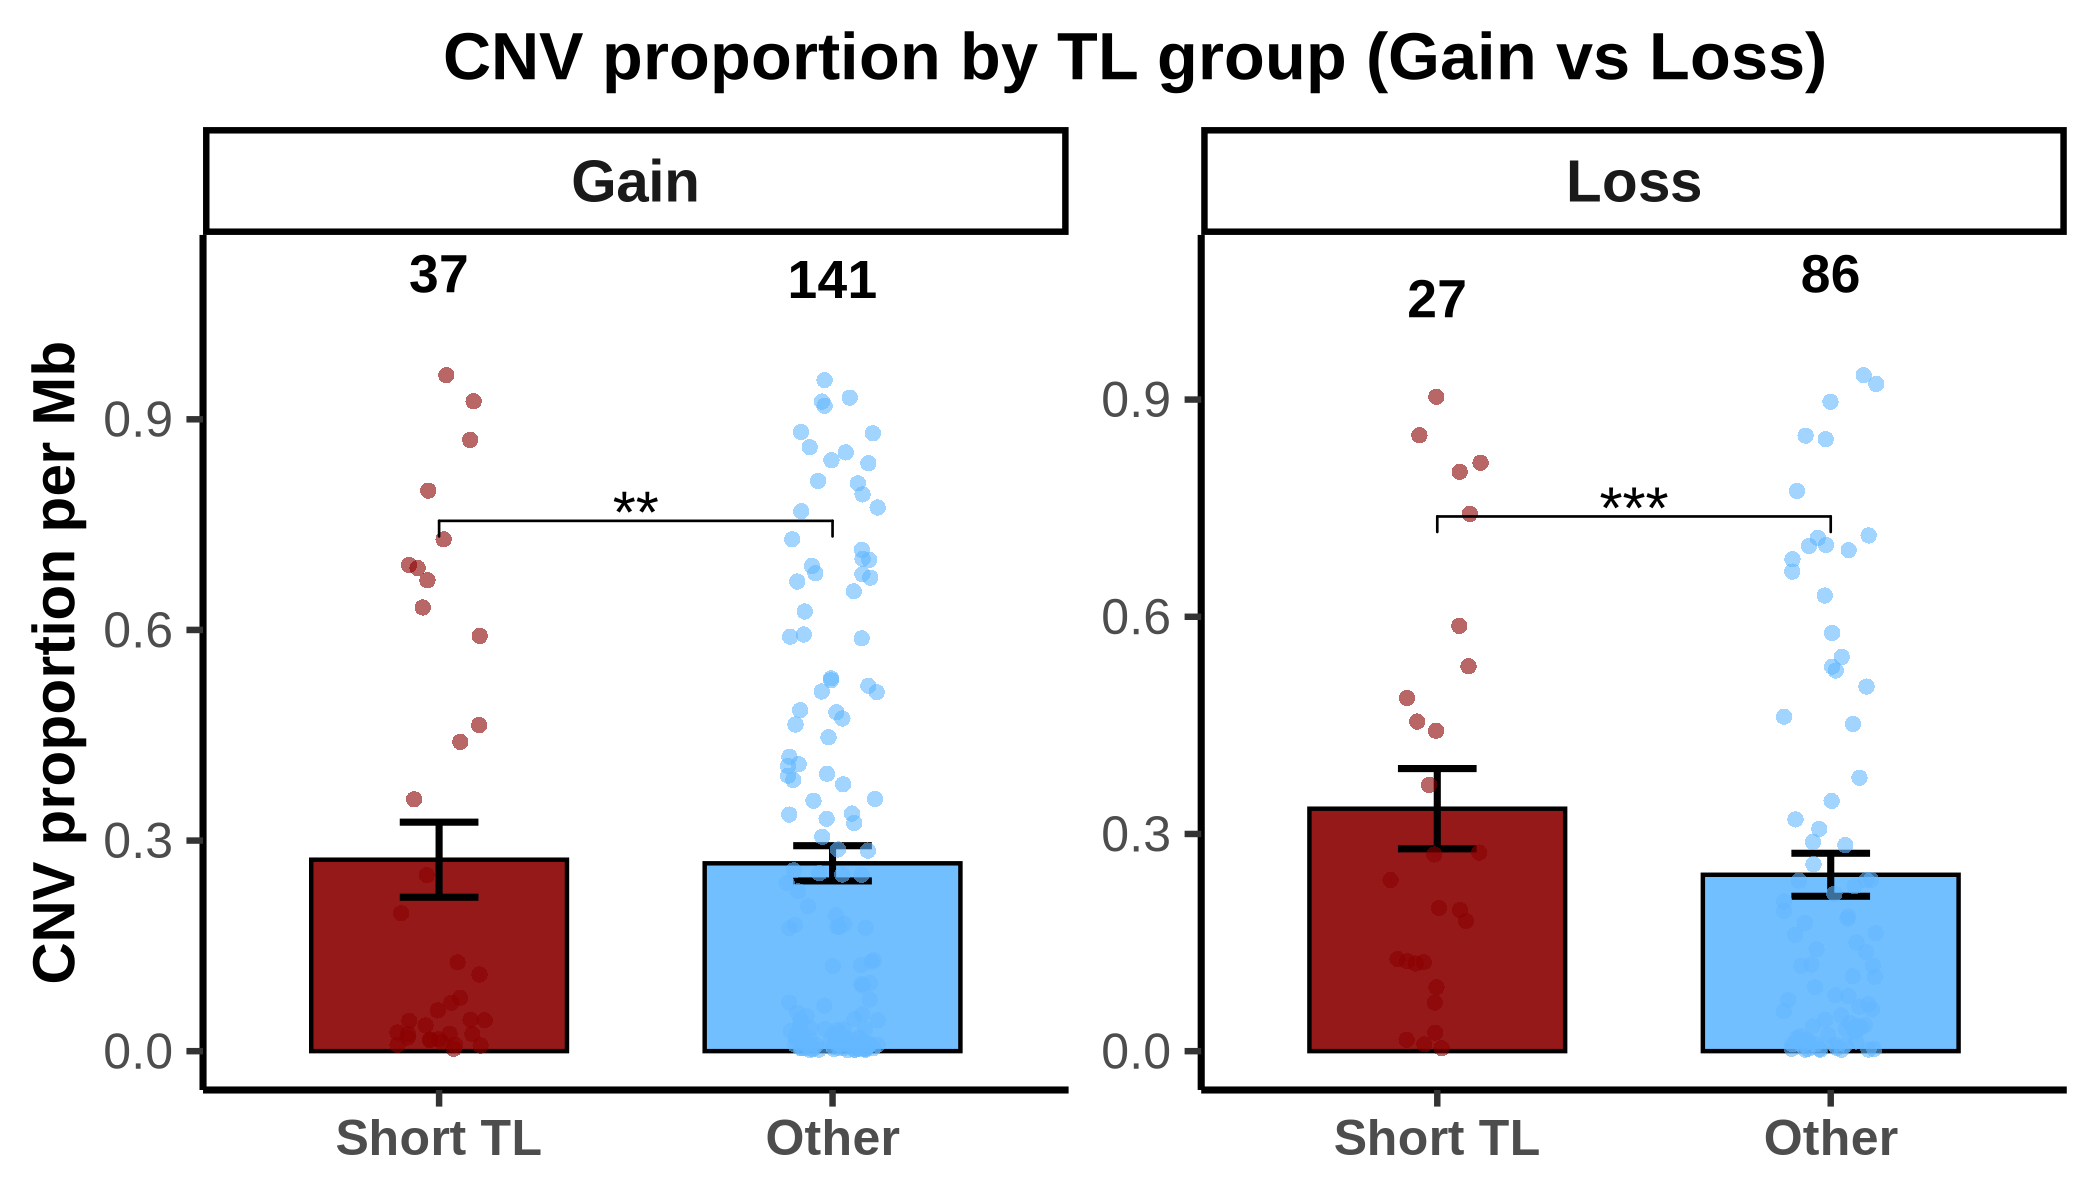

In [65]:
library(dplyr)
library(ggplot2)
library(ggpubr)
library(clubSandwich)

# Function to convert p-values to significance stars
p_to_stars <- function(p) {
  ifelse(is.na(p), "NA",
         ifelse(p < 0.001, "***",
                ifelse(p < 0.01, "**",
                       ifelse(p < 0.05, "*", "ns"))))
}

make_cnv_gainloss_bar <- function(df, ycol, ylab, title_text) {

  # Prepare data
  d <- df %>%
    transmute(
      ID        = factor(ID),
      arm       = factor(arm),
      Gain_Loss = factor(Gain_Loss),
      TL_group  = factor(TL_group, levels = c("Short TL", "Other")),
      y_raw     = as.numeric(.data[[ycol]]),
      y         = log1p(as.numeric(.data[[ycol]]))
    ) %>%
    filter(is.finite(y))

  # Compute p-values per Gain_Loss group
  pvals <- d %>%
    group_split(Gain_Loss) %>%
    lapply(function(dd) {
      fit <- lm(y ~ TL_group + arm + ID, data = dd)
      ct  <- clubSandwich::coef_test(fit, vcov = "CR2", cluster = dd$ID)
      p   <- ct["TL_groupOther", "p_Satt"]

      data.frame(
        Gain_Loss  = unique(dd$Gain_Loss),
        group1 = "Short TL", group2 = "Other",
        y.position = max(dd$y, na.rm = TRUE) * 1.12,
        p = as.numeric(p),
        p.signif = p_to_stars(as.numeric(p))
      )
    }) %>%
    bind_rows()

  # Compute counts per TL_group and Gain_Loss for labels
  counts <- d %>%
    group_by(Gain_Loss, TL_group) %>%
    summarise(n = n(), y_raw_max = max(y_raw, na.rm = TRUE), .groups = "drop")

  # Plot
  ggplot(d, aes(x = TL_group, y = y_raw, fill = TL_group)) +
    # Bars: mean ± SE
    stat_summary(fun = mean, geom = "col", width = 0.65, alpha = 0.9, color = "black") +
    stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.2, linewidth = 0.8) +
    
    # Jitter points
    geom_jitter(aes(color = TL_group), width = 0.12, size = 1.5, alpha = 0.6, shape = 16) +
    
    # Facet by Gain_Loss
    facet_wrap(~ Gain_Loss, nrow = 1, scales = "free_y") +
    
    # P-values from linear model
    ggpubr::stat_pvalue_manual(
      pvals,
      label = "p.signif",
      tip.length = 0.02,
      size = 5,
      inherit.aes = FALSE
    ) +
    
    # Number of points above bars
    geom_text(data = counts, 
              aes(x = TL_group, y = y_raw_max * 1.15, label = n), 
              inherit.aes = FALSE, size = 4.5, fontface = "bold") +
    
    # Colors
    scale_fill_manual(values = c("Short TL" = "darkred", "Other" = "steelblue1")) +
    scale_color_manual(values = c("Short TL" = "darkred", "Other" = "steelblue1")) +
    
    # Labels
    labs(
      title = title_text,
      x = NULL, y = ylab
    ) +
    
    # Theme adjustments
    theme_classic(base_size = 16) +
    theme(
      strip.text = element_text(face = "bold", size = 14),
      axis.title.y = element_text(face = "bold", size = 14),
      axis.text.x = element_text(face = "bold", size = 12),
      axis.text.y = element_text(size = 12),
      plot.title = element_text(face = "bold", hjust = 0.5, size = 16),
      legend.position = "none",
      axis.line = element_line(size = 0.8)
    )
}

# Plot size for publication
options(repr.plot.width = 7, repr.plot.height = 4, repr.plot.res = 300)

# Example usage
p_cnv_rate_gainloss <- make_cnv_gainloss_bar(
  merged_cnv_data,
  ycol = "cnv_rate_per_mb",
  ylab = "CNV rate per Mb",
  title_text = "CNV rate by TL group (Gain vs Loss)"
)

p_cnv_prop_gainloss <- make_cnv_gainloss_bar(
  merged_cnv_data,
  ycol = "cnv_proportion_per_mb",
  ylab = "CNV proportion per Mb",
  title_text = "CNV proportion by TL group (Gain vs Loss)"
)

# Print plots
print(p_cnv_rate_gainloss)
print(p_cnv_prop_gainloss)
